# 08 — Final honest test evaluation

Model selection is complete. This notebook evaluates the selected epoch-7 checkpoint exactly once on the 294-image official test split. It does **not** train, change weights, or make further model choices from this result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

BATCH_SIZE = 16
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SELECTED_CLASSES = ['Abyssinian', 'Bengal', 'Egyptian Mau']

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
print('This is final evaluation mode: no training or model selection will happen here.')

PyTorch: 2.13.0+cpu
Device:  cpu
This is final evaluation mode: no training or model selection will happen here.


In [2]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / 'pyproject.toml').exists() else CURRENT_FOLDER.parent
METADATA_PATH = PROJECT_ROOT / 'data' / 'classification_crops' / 'metadata.csv'
SELECTED_CHECKPOINT_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_best_epoch6_to_10.pt'

assert METADATA_PATH.exists(), f'Missing crop metadata: {METADATA_PATH}'
assert SELECTED_CHECKPOINT_PATH.exists(), f'Missing selected checkpoint: {SELECTED_CHECKPOINT_PATH}'
records = pd.read_csv(METADATA_PATH)
test_records = records.query("split == 'test'").reset_index(drop=True)

assert len(test_records) == 294
assert set(test_records['class_name']) == set(SELECTED_CLASSES)
display(test_records.groupby('class_name').size().rename('official_test_examples').to_frame())
print('These official test records have not been used in training or validation-based model selection.')

,official_test_examples
class_name,
Abyssinian,98
Bengal,100
Egyptian Mau,96


These official test records have not been used in training or validation-based model selection.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PetCropDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            image = image.convert('RGB')
        return self.transform(image), int(row['label_id'])

test_loader = DataLoader(PetCropDataset(test_records, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f'Official test batches: {len(test_loader)}')
print('The transform is deterministic, so every test crop receives the same evaluation processing.')

Official test batches: 19
The transform is deterministic, so every test crop receives the same evaluation processing.


In [4]:
checkpoint = torch.load(SELECTED_CHECKPOINT_PATH, map_location=DEVICE, weights_only=True)
assert checkpoint['class_names'] == SELECTED_CLASSES

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(SELECTED_CLASSES))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(DEVICE).eval()

print(f"Selected validation epoch: {checkpoint['best_epoch']}")
print(f"Selected validation accuracy: {checkpoint['best_val_accuracy']:.1%}")
print('The model is loaded in eval() mode; its weights are fixed for this final measurement.')

Selected validation epoch: 7
Selected validation accuracy: 82.8%
The model is loaded in eval() mode; its weights are fixed for this final measurement.


## Make final test predictions

`torch.no_grad()` means PyTorch does not calculate gradients. This makes evaluation lighter and also makes clear that the model is not learning from test labels.

In [5]:
all_true_ids, all_predicted_ids, all_probabilities = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        probabilities = torch.softmax(model(images.to(DEVICE)), dim=1)
        all_true_ids.extend(labels.tolist())
        all_predicted_ids.extend(probabilities.argmax(dim=1).cpu().tolist())
        all_probabilities.extend(probabilities.cpu().tolist())

results = test_records[['image_id', 'class_name', 'label_id', 'crop_path']].copy()
results = results.rename(columns={'class_name': 'true_class', 'label_id': 'true_id'})
results['predicted_id'] = all_predicted_ids
results['predicted_class'] = [SELECTED_CLASSES[class_id] for class_id in all_predicted_ids]
results['correct'] = results['true_id'] == results['predicted_id']
for class_id, class_name in enumerate(SELECTED_CLASSES):
    results[f'P({class_name})'] = [row[class_id] for row in all_probabilities]

assert len(results) == len(test_records)
display(results.head().round(3))

,image_id,true_class,true_id,crop_path,predicted_id,predicted_class,correct,P(Abyssinian),P(Bengal),P(Egyptian Mau)
0,Abyssinian_2,Abyssinian,0,data/classification_crops/test/Abyssinian/Abys...,0,Abyssinian,True,0.808,0.081,0.111
1,Abyssinian_20,Abyssinian,0,data/classification_crops/test/Abyssinian/Abys...,0,Abyssinian,True,0.892,0.093,0.015
2,Abyssinian_201,Abyssinian,0,data/classification_crops/test/Abyssinian/Abys...,0,Abyssinian,True,0.745,0.193,0.062
3,Abyssinian_202,Abyssinian,0,data/classification_crops/test/Abyssinian/Abys...,0,Abyssinian,True,0.807,0.109,0.084
4,Abyssinian_204,Abyssinian,0,data/classification_crops/test/Abyssinian/Abys...,0,Abyssinian,True,0.801,0.150,0.049


In [6]:
test_accuracy = results['correct'].mean()
correct_count = int(results['correct'].sum())
majority_class = test_records['class_name'].value_counts().idxmax()
majority_baseline = (test_records['class_name'] == majority_class).mean()

print(f'Final official test accuracy: {test_accuracy:.1%} ({correct_count}/{len(results)} correct)')
print(f'Majority-class test baseline: {majority_baseline:.1%} (always predict {majority_class})')
print(f'Validation-to-test difference: {checkpoint["best_val_accuracy"] - test_accuracy:+.1%}')
print('This is a final report, not a signal to tune the model further.')

Final official test accuracy: 82.7% (243/294 correct)
Majority-class test baseline: 34.0% (always predict Bengal)
Validation-to-test difference: +0.1%
This is a final report, not a signal to tune the model further.


## Final class-by-class report

Rows in the confusion matrix are true classes; columns are predictions. Precision, recall, and F1 provide class-level detail beyond the single overall accuracy number.

predicted class,Abyssinian,Bengal,Egyptian Mau
true class,,,
Abyssinian,83,13,2
Bengal,9,89,2
Egyptian Mau,5,20,71


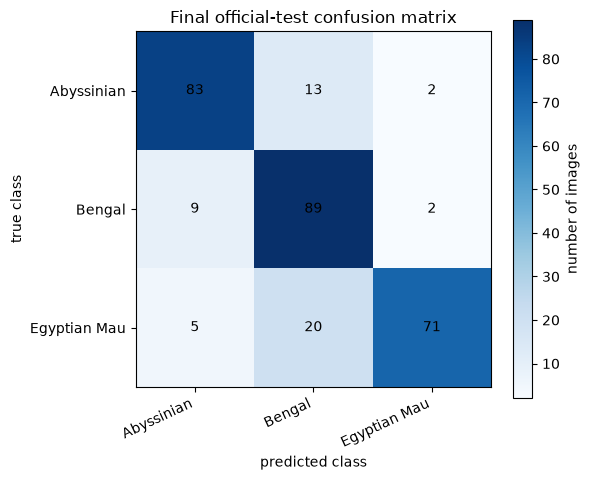

In [7]:
confusion = pd.crosstab(
    pd.Categorical(results['true_class'], categories=SELECTED_CLASSES),
    pd.Categorical(results['predicted_class'], categories=SELECTED_CLASSES),
    rownames=['true class'], colnames=['predicted class'], dropna=False,
)
display(confusion)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion.to_numpy(), cmap='Blues')
ax.set(xticks=range(3), yticks=range(3), xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, xlabel='predicted class', ylabel='true class', title='Final official-test confusion matrix')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
for row in range(3):
    for column in range(3):
        ax.text(column, row, confusion.iloc[row, column], ha='center', va='center')
fig.colorbar(image, ax=ax, label='number of images')
plt.tight_layout()
plt.show()

In [8]:
per_class_rows = []
for class_name in SELECTED_CLASSES:
    true_positive = int(((results['true_class'] == class_name) & (results['predicted_class'] == class_name)).sum())
    false_positive = int(((results['true_class'] != class_name) & (results['predicted_class'] == class_name)).sum())
    false_negative = int(((results['true_class'] == class_name) & (results['predicted_class'] != class_name)).sum())
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0.0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    per_class_rows.append({'class': class_name, 'precision': precision, 'recall': recall, 'f1': f1, 'support': true_positive + false_negative})

per_class = pd.DataFrame(per_class_rows).set_index('class')
display(per_class.round(3))

,precision,recall,f1,support
class,,,,
Abyssinian,0.856,0.847,0.851,98
Bengal,0.730,0.890,0.802,100
Egyptian Mau,0.947,0.740,0.830,96


## Inspect a sample of final test mistakes

These images explain the final reported result. We inspect them to describe limitations, not to make new model changes.

In [9]:
errors = results.loc[~results['correct']].copy()
probability_columns = [f'P({class_name})' for class_name in SELECTED_CLASSES]
error_probability_matrix = errors[probability_columns].to_numpy()
errors['predicted_probability'] = error_probability_matrix[np.arange(len(errors)), errors['predicted_id'].to_numpy()]
errors = errors.sort_values('predicted_probability', ascending=False)
display(errors[['image_id', 'true_class', 'predicted_class', 'predicted_probability', *probability_columns]].head(12).round(3))
print(f'Final test errors: {len(errors)}. This table is descriptive only; no training follows it.')

,image_id,true_class,predicted_class,predicted_probability,P(Abyssinian),P(Bengal),P(Egyptian Mau)
92,Abyssinian_94,Abyssinian,Bengal,0.834,0.140,0.834,0.027
278,Egyptian_Mau_85,Egyptian Mau,Bengal,0.792,0.066,0.792,0.142
211,Egyptian_Mau_214,Egyptian Mau,Bengal,0.758,0.051,0.758,0.191
58,Abyssinian_61,Abyssinian,Bengal,0.729,0.235,0.729,0.037
135,Bengal_42,Bengal,Abyssinian,0.718,0.718,0.233,0.049
163,Bengal_68,Bengal,Abyssinian,0.715,0.715,0.241,0.044
259,Egyptian_Mau_63,Egyptian Mau,Bengal,0.713,0.040,0.713,0.247
226,Egyptian_Mau_29,Egyptian Mau,Bengal,0.683,0.092,0.683,0.225
250,Egyptian_Mau_54,Egyptian Mau,Bengal,0.674,0.049,0.674,0.277
176,Bengal_8,Bengal,Abyssinian,0.670,0.670,0.303,0.027


Final test errors: 51. This table is descriptive only; no training follows it.


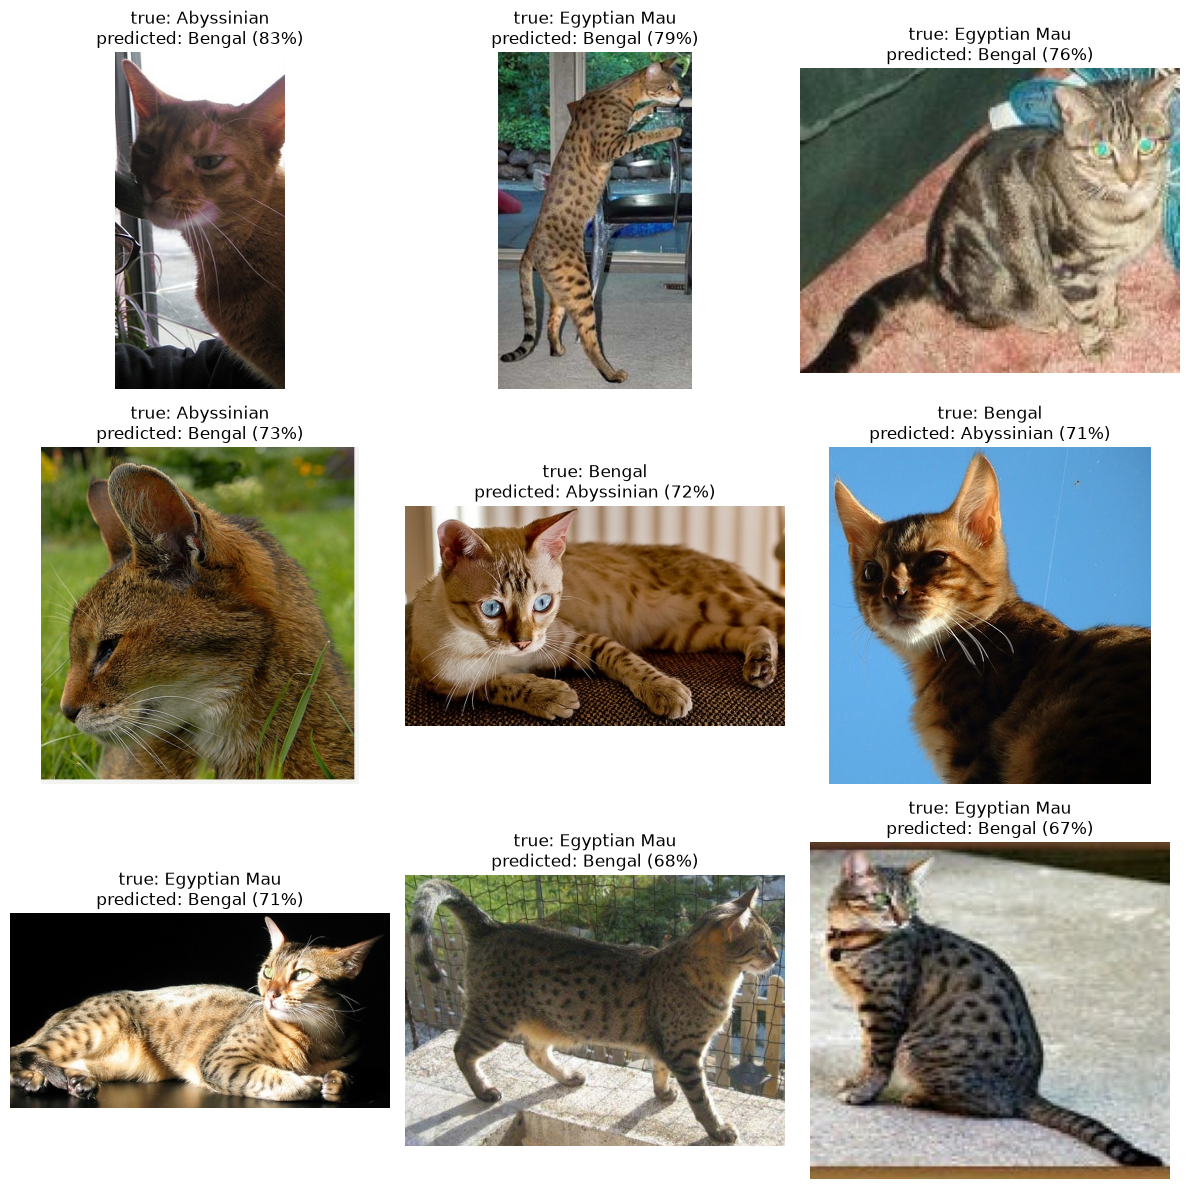

In [10]:
MAX_TO_SHOW = 9
examples = errors.head(MAX_TO_SHOW).reset_index(drop=True)
if examples.empty:
    print('No test errors to display.')
else:
    columns = 3
    rows = int(np.ceil(len(examples) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, examples.iterrows()):
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f"true: {row['true_class']}\npredicted: {row['predicted_class']} ({row['predicted_probability']:.0%})")
        ax.axis('off')
    for ax in axes[len(examples):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### Final reporting checkpoint

Save this notebook after running it. Report the final accuracy, confusion matrix, per-class table, and representative mistakes honestly. Do not use the test result to claim further tuning improvements.